# Editing intial file to include passive tracer

In [1]:
# Loading in modules

import subprocess
import os
import pandas as pd
import netCDF4
import numpy as np
import glob
import time
import matplotlib.pyplot as plt
import copy

import xarray as xr
from datetime import datetime, timedelta 
import dask
from scipy.interpolate import griddata
#from ocean_c_lab_tools import *
#from celluloid import Camera 
#import PyCO2SYS as csys
#import seawater as sw
from roms_regrid import *

In [2]:
infile=xr.open_dataset('/home/x-uheede/S/Iceland2_NOMARBL_2024_RST/Iceland2_MARBL_2024_rst.20240617130000.nc')

In [3]:
infile

<xarray.Dataset> Size: 2GB
Dimensions:     (time: 2, auxil: 6, eta_rho: 514, xi_rho: 514, xi_u: 513,
                 eta_v: 513, s_rho: 60)
Dimensions without coordinates: time, auxil, eta_rho, xi_rho, xi_u, eta_v, s_rho
Data variables: (12/24)
    ocean_time  (time) float64 16B ...
    time_step   (time, auxil) int32 48B ...
    zeta        (time, eta_rho, xi_rho) float64 4MB ...
    ubar        (time, eta_rho, xi_u) float64 4MB ...
    vbar        (time, eta_v, xi_rho) float64 4MB ...
    u           (time, s_rho, eta_rho, xi_u) float64 253MB ...
    ...          ...
    v_slow      (time, s_rho, eta_v, xi_rho) float64 253MB ...
    p_slow      (time, s_rho, eta_rho, xi_rho) float64 254MB ...
    ub_west     (time, eta_rho) float64 8kB ...
    ub_east     (time, eta_rho) float64 8kB ...
    ub_north    (time, xi_rho) float64 8kB ...
    ub_south    (time, xi_rho) float64 8kB ...
Attributes: (12/44)
    global_x:           512
    global_y:           512
    title:              Iceland2_MARBL_2024 , 200 m  resolution
    grid_file:          /anvil/scratch/x-uheede/Iceland2_MARBL_2024_60m/P_INP...
    forcing_files:       /anvil/scratch/x-uheede/Iceland2_MARBL_2024_60m/P_IN...
    forcing_info:       
    ...                 ...
    tide_options:       # of constituents:10 , real , tidalpotential
    river_frc_options:  OFF
    pipe_frc_options:   OFF
    particle_options:   OFF
    git_version:        
    type:               ROMS restart file

In [4]:
grid=xr.open_dataset("/home/x-uheede/S/Iceland2_MARBL_2024_60m/P_INPUT/Iceland2_grid_MAT1.nc")

In [5]:
grid.load()

<xarray.Dataset> Size: 19MB
Dimensions:    (one: 1, eta_rho: 514, xi_rho: 514)
Dimensions without coordinates: one, eta_rho, xi_rho
Data variables: (12/14)
    spherical  (one) |S1 1B b'T'
    angle      (eta_rho, xi_rho) float64 2MB 0.01645 0.01645 ... -0.01701
    h          (eta_rho, xi_rho) float64 2MB 132.7 132.7 132.5 ... 5.0 5.0 5.0
    hraw       (eta_rho, xi_rho) float64 2MB 134.3 132.5 130.2 ... -0.2 -0.2
    f          (eta_rho, xi_rho) float64 2MB 0.0001306 0.0001306 ... 0.0001316
    pm         (eta_rho, xi_rho) float64 2MB 0.005 0.005 0.005 ... 0.005 0.005
    ...         ...
    lat_rho    (eta_rho, xi_rho) float64 2MB 63.91 63.91 63.91 ... 64.84 64.84
    mask_rho   (eta_rho, xi_rho) float64 2MB 1.0 1.0 1.0 1.0 ... 0.0 0.0 0.0 0.0
    tra_lon    (one) float64 8B -22.3
    tra_lat    (one) float64 8B 64.38
    rotate     (one) float64 8B 0.0
    xy_flip    (one) float64 8B 9.969e+36
Attributes:
    Title:    ROMS grid by Easy Grid. Settings: nx: 512 ny: 512 xsize: 102.4 ...
    Date:     23-Oct-2025
    Type:     ROMS grid produced by Easy Grid

In [6]:
infile["dye"] = xr.zeros_like(infile["temp"])
infile["dye"].attrs.update({
    "long_name": "Passive dye tracer",
    "units": "stuff per m3"
})

In [7]:
import numpy as np

# Points (lat, lon)
points = [
    (64.3974, -21.6455 + 360),  # point A
    (64.3710, -21.6128 + 360),  # point B
]


In [8]:
latg = grid["lat_rho"].values
long = grid["lon_rho"].values

indices = []

for lat, lon in points:
    dist2 = (latg - lat)**2 + (long - lon)**2
    eta, xi = np.unravel_index(np.argmin(dist2), latg.shape)
    indices.append((eta, xi))

# Results
(eta0, xi0), (eta1, xi1) = indices

print("Point A (eta, xi):", eta0, xi0)
print("Point B (eta, xi):", eta1, xi1)


Point A (eta, xi): 267 414
Point B (eta, xi): 252 422


In [9]:
import numpy as np

def bresenham_line(eta0, xi0, eta1, xi1):
    """Return list of (eta, xi) indices along shortest grid-cell line."""
    points = []

    d_eta = abs(eta1 - eta0)
    d_xi  = abs(xi1 - xi0)

    s_eta = 1 if eta0 < eta1 else -1
    s_xi  = 1 if xi0 < xi1 else -1

    err = d_eta - d_xi

    eta, xi = eta0, xi0

    while True:
        points.append((eta, xi))

        if eta == eta1 and xi == xi1:
            break

        e2 = 2 * err
        if e2 > -d_xi:
            err -= d_xi
            eta += s_eta
        if e2 < d_eta:
            err += d_eta
            xi += s_xi

    return np.array(points)


In [10]:
eta0, xi0 = 267, 414
eta1, xi1 = 252, 422

line_indices = bresenham_line(eta0, xi0, eta1, xi1)

print("Number of grid cells:", len(line_indices))
print(line_indices)


Number of grid cells: 16
[[267 414]
 [266 415]
 [265 415]
 [264 416]
 [263 416]
 [262 417]
 [261 417]
 [260 418]
 [259 418]
 [258 419]
 [257 419]
 [256 420]
 [255 420]
 [254 421]
 [253 421]
 [252 422]]


In [11]:
for eta, xi in line_indices:
    infile["dye"][:, 54, eta, xi] = 100

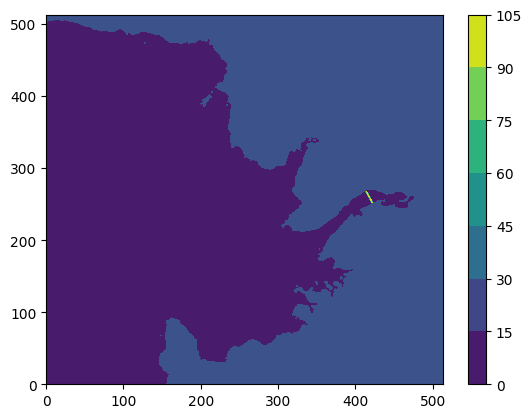

In [12]:

cf=plt.contourf(infile["dye"][1, 54,:,:])
plt.contourf(grid['mask_rho'].where(grid['mask_rho']<1))
plt.colorbar(cf)

In [13]:
infile.to_netcdf('/anvil/scratch/x-uheede/Iceland2_NOMARBL_2024_DYE_RHALF/dye_initial_conditions.nc')
infile.to_netcdf('/anvil/scratch/x-uheede/Iceland2_NOMARBL_2024_DYE_NewV/dye_initial_conditions.nc')

# read in and modify the boundary files

In [14]:
bryfiles='/anvil/scratch/x-uheede/Iceland2_NOMARBL_2024_DYE_RHALF/P_INPUT/*bry*2024??????????.nc' 

In [15]:
bry=xr.open_mfdataset(bryfiles, combine='nested', concat_dim=["time"])

/tmp/ipykernel_220080/4208825334.py:1: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  bry=xr.open_mfdataset(bryfiles, combine='nested', concat_dim=["time"])
/tmp/ipykernel_220080/4208825334.py:1: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding

In [16]:
import xarray as xr
import numpy as np
import glob
import os

# File pattern
bryfiles = '/anvil/scratch/x-uheede/Iceland2_NOMARBL_2024_DYE_RHALF/P_INPUT/*bry*2024??????????.nc'

files = sorted(glob.glob(bryfiles))

print(f"Found {len(files)} files")

for f in files:
    print(f"Processing {os.path.basename(f)}")

    # Open dataset
    ds = xr.open_dataset(f)

    # Sanity check
    if "temp_west" not in ds:
        raise KeyError(f"'temp_west' not found in {f}")

    # Create zero-filled DataArrays
    zero_west = xr.zeros_like(ds["temp_west"])
    zero_south = xr.zeros_like(ds["temp_west"])

    # Add to dataset
    ds["dye_west"] = zero_west
    ds["dye_south"] = zero_south

    # Optional metadata (recommended)
    ds["dye_west"].attrs = {
        "long_name": "Dye concentration at western boundary",
        "units": "arbitrary"
    }

    ds["dye_south"].attrs = {
        "long_name": "Dye concentration at southern boundary",
        "units": "arbitrary"
    }

    # Output filename
    outname = f.replace(".nc", "_withdye.nc")

    # Write new file
    ds.to_netcdf(outname)

    ds.close()

print("✅ All files processed successfully.")


Found 14 files
Processing Iceland2_bry.20240716120120.nc


/tmp/ipykernel_220080/2402889182.py:17: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(f)


Processing Iceland2_bry.20240717120120.nc


/tmp/ipykernel_220080/2402889182.py:17: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(f)


Processing Iceland2_bry.20240718120120.nc


...

Processing Iceland2_bry.20240728120120.nc


/tmp/ipykernel_220080/2402889182.py:17: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(f)


Processing Iceland2_bry.20240729120120.nc


/tmp/ipykernel_220080/2402889182.py:17: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(f)


✅ All files processed successfully.
